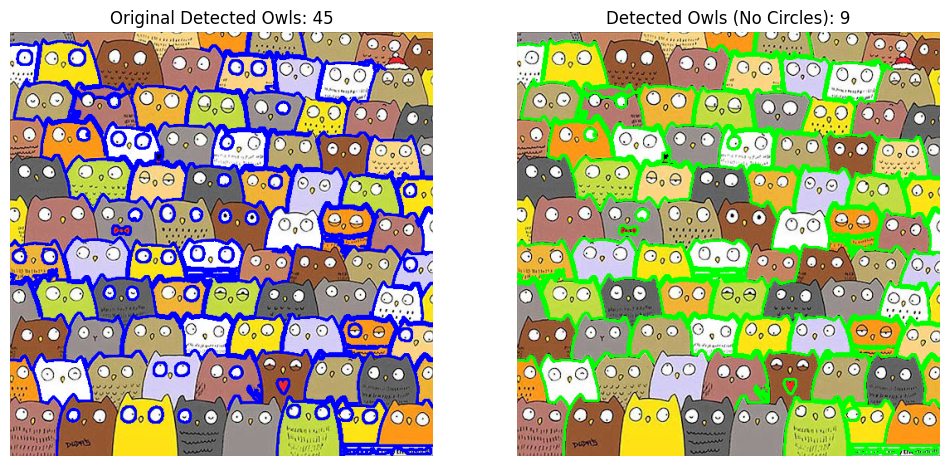

9

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Đọc ảnh từ đường dẫn
image_path = "/Users/kaiser_1/Documents/GitHub/Image-processing-and-analysis/midterm/image/cat.jpg"  # Thay thế bằng đường dẫn ảnh thực tế
image = cv2.imread(image_path)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Áp dụng bộ lọc để phát hiện cạnh
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(blurred, 50, 150)

# Tìm contours
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Lọc bỏ các contours nhỏ
min_contour_area = 150  # Giữ lại các cú nhỏ
filtered_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > min_contour_area]

# Tạo bản sao ảnh để vẽ kết quả
result_image = image.copy()
cv2.drawContours(result_image, filtered_contours, -1, (255, 0, 0), 2)

# Hàm tính độ tròn của một contour
def circularity(contour):
    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)
    if perimeter == 0:
        return 0
    return (4 * np.pi * area) / (perimeter ** 2)

# Ngưỡng để xác định hình tròn (mắt cú)
circularity_threshold = 0.75

# Lọc bỏ các hình tròn (mắt cú)
filtered_contours_no_circles = [
    cnt for cnt in filtered_contours 
    if circularity(cnt) < circularity_threshold
]

# Vẽ contours sau khi loại bỏ hình tròn
result_image_no_circles = image.copy()
cv2.drawContours(result_image_no_circles, filtered_contours_no_circles, -1, (0, 255, 0), 2)

# Số lượng cú sau khi loại bỏ hình tròn
num_owls_no_circles = len(filtered_contours_no_circles)

# Hiển thị kết quả
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
ax[0].set_title(f"Original Detected Owls: {len(filtered_contours)}")
ax[0].axis("off")

ax[1].imshow(cv2.cvtColor(result_image_no_circles, cv2.COLOR_BGR2RGB))
ax[1].set_title(f"Detected Owls (No Circles): {num_owls_no_circles}")
ax[1].axis("off")

plt.show()

# Trả về số lượng cú sau khi loại bỏ hình tròn
num_owls_no_circles


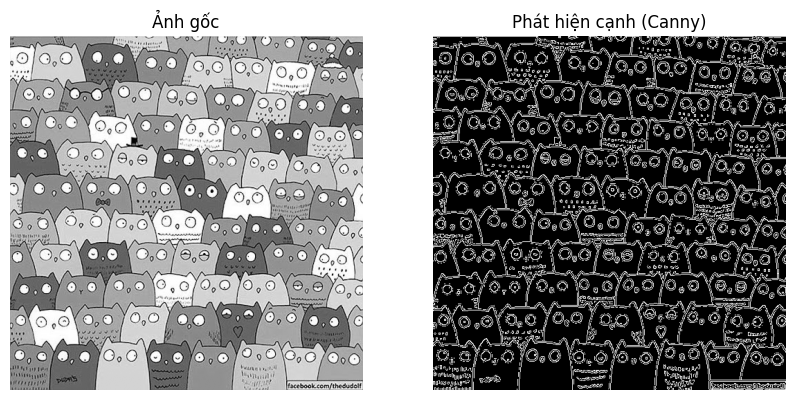

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Đọc ảnh
image_path = "/Users/kaiser_1/Documents/GitHub/Image-processing-and-analysis/midterm/image/cat.jpg"
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Phát hiện cạnh bằng thuật toán Canny
edges = cv2.Canny(image, 100, 200)

# Hiển thị ảnh gốc và ảnh cạnh
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Ảnh gốc")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(edges, cmap="gray")
plt.title("Phát hiện cạnh (Canny)")
plt.axis("off")

plt.show()


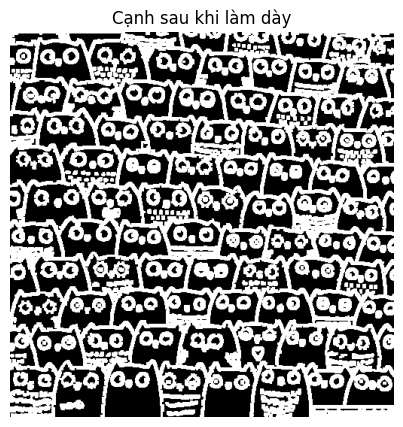

In [2]:
# Làm dày đường viền bằng phép toán giãn nở (Dilation)
kernel = np.ones((3,3), np.uint8)  # Kernel 3x3 để làm dày cạnh
image_binary = cv2.dilate(edges, kernel, iterations=1)

# Hiển thị ảnh cạnh đã làm dày
plt.figure(figsize=(5, 5))
plt.imshow(image_binary, cmap="gray")
plt.title("Cạnh sau khi làm dày")
plt.axis("off")
plt.show()


In [ ]:
# Tìm các thành phần liên thông (vùng màu đen) trong ảnh nhị phân
num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(image_binary, connectivity=8)


area_threshold = 120
large_black_regions = sum(1 for stat in stats if stat[cv2.CC_STAT_AREA] > area_threshold)

large_black_regions


94

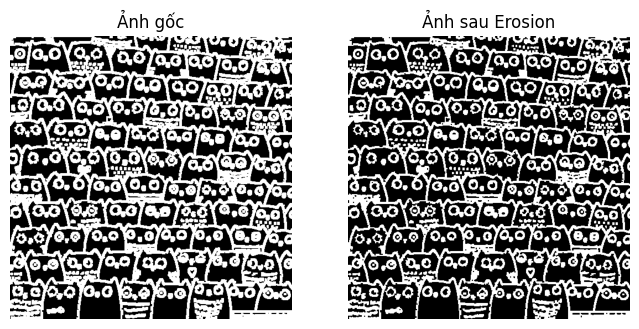

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Tạo kernel (cấu trúc phần tử)
kernel = np.ones((2,2), np.uint8)

# Áp dụng phép co (erosion)
eroded_image = cv2.erode(image_binary, kernel, iterations=1)

# Hiển thị kết quả
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(image_binary, cmap='gray')
axes[0].set_title('Ảnh gốc')
axes[0].axis('off')

axes[1].imshow(eroded_image, cmap='gray')
axes[1].set_title('Ảnh sau Erosion')
axes[1].axis('off')

plt.show()

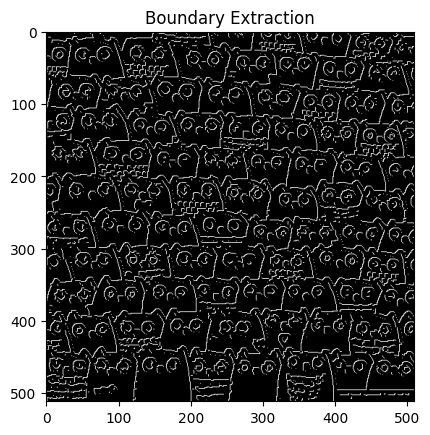

In [5]:
boundary = image_binary - eroded_image
plt.imshow(boundary, cmap='gray')
plt.title('Boundary Extraction')
plt.show()

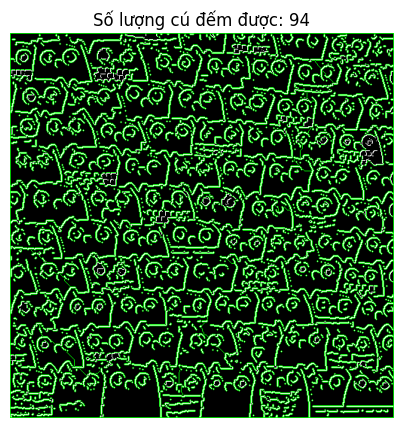

94

In [ ]:

_, binary = cv2.threshold(boundary, 50, 255, cv2.THRESH_BINARY_INV)

# Sử dụng khoảng cách Euclidean (Distance Transform) để tách các vùng dính nhau
dist_transform = cv2.distanceTransform(binary, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist_transform, 0.4 * dist_transform.max(), 255, 0)

# Chuyển đổi kiểu dữ liệu
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(binary, sure_fg)

# Áp dụng Watershed để tách đối tượng
markers = cv2.connectedComponents(sure_fg)[1]
markers = markers + 1  # Để đảm bảo các vùng nền có giá trị khác 0
markers[unknown == 255] = 0  # Đánh dấu vùng không xác định


image_color = cv2.cvtColor(boundary, cv2.COLOR_GRAY2BGR)
cv2.watershed(image_color, markers)
image_color[markers == -1] = [0, 255, 0]  # Đánh dấu viền vùng bằng màu xanh lá

# Hiển thị kết quả
plt.figure(figsize=(10,5))
plt.imshow(image_color)
plt.title(f"Số lượng cú đếm được: {large_black_regions}")
plt.axis("off")
plt.show()

# Trả về số lượng cú đếm được
large_black_regions

### Hough Transform


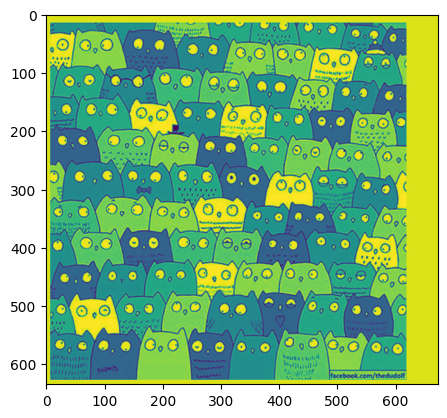

In [15]:
import numpy as np 
import cv2
import matplotlib.pyplot as plt
path = "/Users/kaiser_1/Documents/GitHub/Image-processing-and-analysis/midterm/image/cat1.jpeg"
image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
plt.imshow(image)

161


True

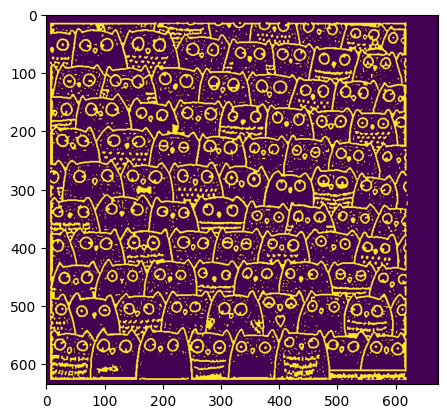

In [ ]:
blurred = cv2.GaussianBlur(image, (0, 0), 1.)
kernel = np.ones([3, 3])
# threshold = (sharpen < 60).astype(np.uint8) * 255
threshold = cv2.adaptiveThreshold(blurred, 
                                    30, 
                                    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                    cv2.THRESH_BINARY_INV,
                                    9,
                                    2)
threshold = cv2.morphologyEx(threshold, cv2.MORPH_CLOSE , kernel, 1)

plt.imshow(threshold)
circles = cv2.HoughCircles(threshold, 
                            method=cv2.HOUGH_GRADIENT, 
                            dp=1, 
                            minDist=30,
                            param1=50,
                            param2=10,
                            minRadius=8,
                            maxRadius=11)
print(len(circles[0]))
viz = image.copy()[..., None].repeat(3, axis=2).astype(np.uint8)
if circles is not None:
    circles = np.uint16(np.around(circles))
    for i in circles[0, :]:
        center = (i[0], i[1])
        # circle center
        cv2.circle(viz, center, 1, (0, 0, 255), 3)
        # circle outline
        radius = i[2]
        cv2.circle(viz, center, radius, (255, 0, 255), 2)
cv2.imwrite("output.jpeg", viz)

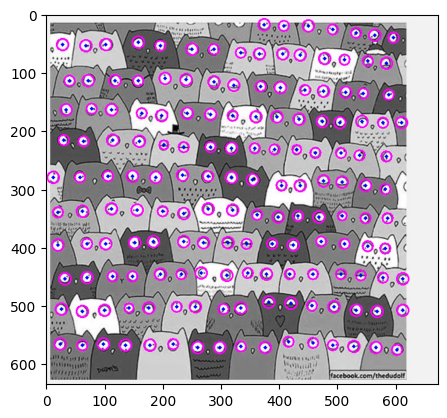

In [17]:
plt.imshow(viz)